In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, TimeSeriesSplit
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, accuracy_score, f1_score, precision_recall_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from catboost import CatBoostClassifier, Pool
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK, space_eval
from functools import partial
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.pipeline import Pipeline
from sklearn.utils import resample

In [2]:
df = pd.read_csv('train_transaction.csv')

In [3]:
df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
df.shape

(590540, 394)

In [5]:
print('%20s %18s %18s %6s' %('Имя', 'Тип данных', 'Кол-во пропусков', '%'))
for col in df.columns[:17]:
    print('%20s %15s %13d %15.1f' %(col, df[col].dtypes, df[col].isna().sum(), df[col].isna().sum() / df.shape[0] * 100))

                 Имя         Тип данных   Кол-во пропусков      %
       TransactionID           int64             0             0.0
             isFraud           int64             0             0.0
       TransactionDT           int64             0             0.0
      TransactionAmt         float64             0             0.0
           ProductCD          object             0             0.0
               card1           int64             0             0.0
               card2         float64          8933             1.5
               card3         float64          1565             0.3
               card4          object          1577             0.3
               card5         float64          4259             0.7
               card6          object          1571             0.3
               addr1         float64         65706            11.1
               addr2         float64         65706            11.1
               dist1         float64        352271            5

In [6]:
ident_df = pd.read_csv('train_identity.csv')

In [7]:
ident_df.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


In [8]:
print('%20s %18s %18s %6s' %('Имя', 'Тип данных', 'Кол-во пропусков', '%'))
for col in ident_df.columns:
    print('%20s %15s %13d %15.1f' %(col, ident_df[col].dtypes, ident_df[col].isna().sum(), ident_df[col].isna().sum() / ident_df.shape[0] * 100))

                 Имя         Тип данных   Кол-во пропусков      %
       TransactionID           int64             0             0.0
               id_01         float64             0             0.0
               id_02         float64          3361             2.3
               id_03         float64         77909            54.0
               id_04         float64         77909            54.0
               id_05         float64          7368             5.1
               id_06         float64          7368             5.1
               id_07         float64        139078            96.4
               id_08         float64        139078            96.4
               id_09         float64         69307            48.1
               id_10         float64         69307            48.1
               id_11         float64          3255             2.3
               id_12          object             0             0.0
               id_13         float64         16913            1

In [9]:
data = df.merge(ident_df, how='left', on='TransactionID')

In [10]:
data.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [11]:
data.shape

(590540, 434)

**Перейдем к разведочному анализу данных (EDA)**

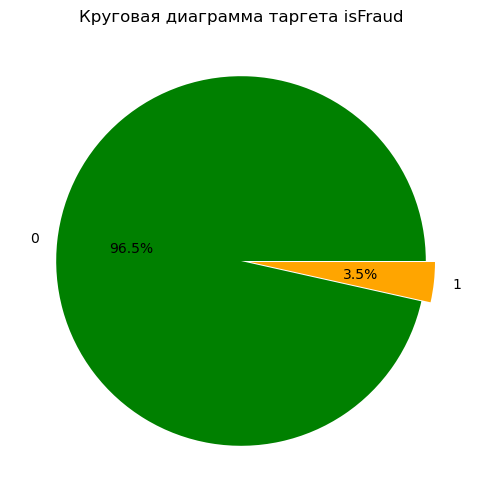

In [45]:
plt.figure(figsize=(10, 6))
plt.pie(
    data.isFraud.value_counts(),
    labels=data.isFraud.value_counts().index,
    autopct='%1.1f%%',
    colors=['green', 'orange'],
    explode=(0, 0.05)
)
plt.title('Круговая диаграмма таргета isFraud')
plt.show()

In [12]:
data["day"] = data["TransactionDT"] // (60 * 60 * 24)

daily_stats = (
    data.groupby("day")
      .agg(
          total_tx=("isFraud", "count"),
          fraud_tx=("isFraud", "sum")
      )
      .reset_index()
)

daily_stats["fraud_rate"] = daily_stats["fraud_tx"] / daily_stats["total_tx"]

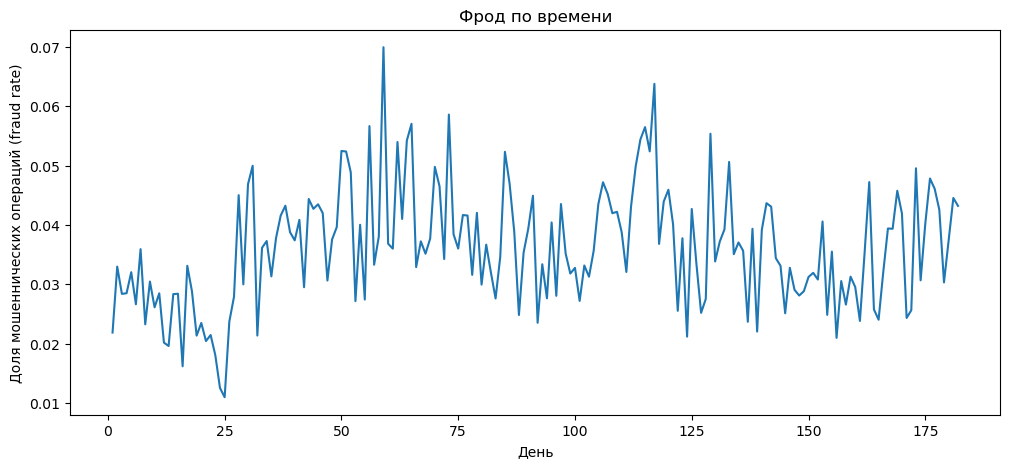

In [13]:
plt.figure(figsize=(12, 5))
plt.plot(daily_stats["day"], daily_stats["fraud_rate"])
plt.xlabel("День")
plt.ylabel("Доля мошеннических операций (fraud rate)")
plt.title("Фрод по времени")
plt.show()

Зависимость мошеннических операций от времени нестационарна, на диаграмме присутствуют явные пики, вследствие чего требуется временная кросс-валидация и мониторинг data drift

<Axes: xlabel='log_amt', ylabel='Density'>

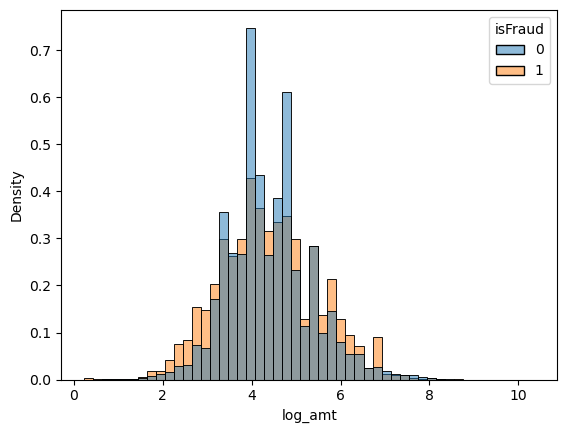

In [14]:
data["log_amt"] = np.log1p(data["TransactionAmt"])

sns.histplot(
    data=data,
    x="log_amt",
    hue="isFraud",
    bins=50,
    stat="density",
    common_norm=False
)

Фрод чаще встречается в средних и высоких суммах транзакций, однако, дублирование с легитимными операциями все же присутствует => нет полноценного разделения операций по суммам

In [15]:
num_data = data.select_dtypes(include=[np.number])
corr = num_data.corr()
corr_with_target = corr["isFraud"].sort_values(ascending=False)

In [16]:
corr_with_target.head(20)

isFraud    1.000000
V257       0.383060
V246       0.366878
V244       0.364129
V242       0.360590
V201       0.328005
V200       0.318783
V189       0.308219
V188       0.303582
V258       0.297151
V45        0.281832
V158       0.278066
V156       0.275952
V149       0.273282
V228       0.268861
V44        0.260376
V86        0.251828
V87        0.251737
V170       0.249794
V147       0.242894
Name: isFraud, dtype: float64

Несколько анонимных V-признаков показывают относительно сильную корреляцию с ярлыком мошенничества, указывая на то, что они фиксируют значимые транзакционные модели, связанные с мошенническим поведением.  

Проверим признаки на дрифт (исследуем для разных дат).

In [17]:
top_features = ["V257","V246","V244","V242","V201","V200","V189","V188","V258",
    "V45","V158","V156","V149","V228","V44","V86","V87","V170","V147"]

cols = top_features + ["isFraud", "day"]

train = data[data["day"] < 120][cols]
valid = data[data["day"] >= 120][cols]

train_corr = train[top_features].corrwith(train["isFraud"])
valid_corr = valid[top_features].corrwith(valid["isFraud"])

corr_check = pd.DataFrame({
    "train_corr": train_corr,
    "valid_corr": valid_corr,
    "abs_diff": (train_corr - valid_corr).abs()
}).sort_values("abs_diff", ascending=False)

In [18]:
corr_check

,train_corr,valid_corr,abs_diff
V258,0.262677,0.416678,0.154001
V170,0.227689,0.295618,0.067929
V246,0.347108,0.410557,0.063450
V228,0.250812,0.308496,0.057684
V257,0.370171,0.411303,0.041133
V189,0.301131,0.333709,0.032578
V242,0.351030,0.381129,0.030100
V149,0.282874,0.252914,0.029960
V156,0.286119,0.258500,0.027619
V200,0.312992,0.340475,0.027483


<Axes: xlabel='day'>

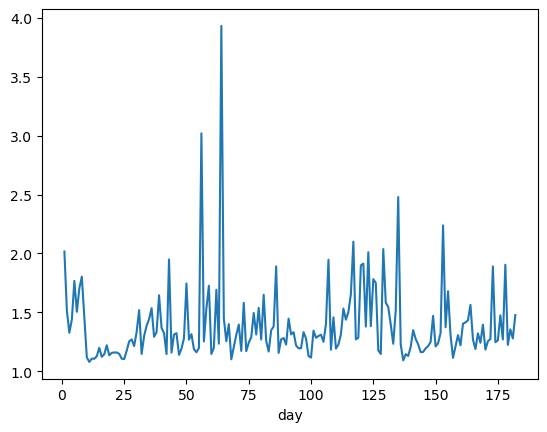

In [19]:
data.groupby("day")["V258"].mean().plot()

Временной анализ признака V258 показывает значительную нестационарность. Функция становится более предсказуемой в более поздние периоды, указывая на эволюцию мошенничества, а не утечку (leak)  
Перейдем к подготовке данных

In [20]:
many_null_cols = [col for col in data.columns if data[col].isnull().sum() / data.shape[0] > 0.9]

In [21]:
big_top_value_cols = [col for col in data.columns if data[col].value_counts(dropna=False, normalize=True).values[0] > 0.9]

In [22]:
one_value_cols = [col for col in train.columns if train[col].nunique() <= 1]

In [23]:
cols_to_drop = list(set(many_null_cols + big_top_value_cols + one_value_cols))
cols_to_drop.remove('isFraud')
len(cols_to_drop)

66

In [24]:
data_for_model = data.drop(cols_to_drop, axis=1)

In [25]:
data_for_model.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,day,log_amt
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,4.241327
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,3.401197
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,4.094345
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,3.931826
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M,1,3.931826


**Feature Engineering: создаем новые признаки**

In [26]:
data_for_model['TransactionAmt_to_mean_card1'] = data_for_model['TransactionAmt'] / data_for_model.groupby(['card1'])['TransactionAmt'].transform('mean')
data_for_model['TransactionAmt_to_mean_card4'] = data_for_model['TransactionAmt'] / data_for_model.groupby(['card4'])['TransactionAmt'].transform('mean')
data_for_model['TransactionAmt_to_std_card1'] = data_for_model['TransactionAmt'] / data_for_model.groupby(['card1'])['TransactionAmt'].transform('std')
data_for_model['TransactionAmt_to_std_card4'] = data_for_model['TransactionAmt'] / data_for_model.groupby(['card4'])['TransactionAmt'].transform('std')

data_for_model['id_02_to_mean_card1'] = data_for_model['id_02'] / data_for_model.groupby(['card1'])['id_02'].transform('mean')
data_for_model['id_02_to_mean_card4'] = data_for_model['id_02'] / data_for_model.groupby(['card4'])['id_02'].transform('mean')
data_for_model['id_02_to_std_card1'] = data_for_model['id_02'] / data_for_model.groupby(['card1'])['id_02'].transform('std')
data_for_model['id_02_to_std_card4'] = data_for_model['id_02'] / data_for_model.groupby(['card4'])['id_02'].transform('std')

data_for_model['D15_to_mean_card1'] = data_for_model['D15'] / data_for_model.groupby(['card1'])['D15'].transform('mean')
data_for_model['D15_to_mean_card4'] = data_for_model['D15'] / data_for_model.groupby(['card4'])['D15'].transform('mean')
data_for_model['D15_to_std_card1'] = data_for_model['D15'] / data_for_model.groupby(['card1'])['D15'].transform('std')
data_for_model['D15_to_std_card4'] = data_for_model['D15'] / data_for_model.groupby(['card4'])['D15'].transform('std')

data_for_model['D15_to_mean_addr1'] = data_for_model['D15'] / data_for_model.groupby(['addr1'])['D15'].transform('mean')
data_for_model['D15_to_mean_addr2'] = data_for_model['D15'] / data_for_model.groupby(['addr2'])['D15'].transform('mean')
data_for_model['D15_to_std_addr1'] = data_for_model['D15'] / data_for_model.groupby(['addr1'])['D15'].transform('std')
data_for_model['D15_to_std_addr2'] = data_for_model['D15'] / data_for_model.groupby(['addr2'])['D15'].transform('std')

In [27]:
data_for_model[['P_emaildomain_1', 'P_emaildomain_2', 'P_emaildomain_3']] = data_for_model['P_emaildomain'].str.split('.', expand=True)
data_for_model[['R_emaildomain_1', 'R_emaildomain_2', 'R_emaildomain_3']] = data_for_model['R_emaildomain'].str.split('.', expand=True)

Заполнение пропущенных значений

In [28]:
num_cols = data_for_model.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = data_for_model.select_dtypes(include=["object", "category"]).columns.tolist()
missing_df = data_for_model.isnull().astype("int8")
missing_df.columns = missing_df.columns + "_is_missing"

data_for_model = pd.concat([data_for_model, missing_df], axis=1)


In [29]:
for col in num_cols:
    if col == "isFraud":
        continue
    median_value = data_for_model[col].median()
    data_for_model[col] = data_for_model[col].fillna(median_value)

In [30]:
for col in cat_cols:
    data_for_model[col] = data_for_model[col].fillna("missing")

In [31]:
data_for_model.isnull().sum().sum()

np.int64(0)

In [32]:
data_for_model = data_for_model.sort_values("day").reset_index(drop=True)

target_col = "isFraud"
time_col = "day"

X = data_for_model.drop(columns=[target_col])
y = data_for_model[target_col].astype(int)

cat_features = cat_cols
cat_feature_indices = [
    X.columns.get_loc(c)
    for c in cat_features
    if c in X.columns
]

In [46]:
def dynamic_threshold_by_recall(
    y_true, y_prob,
    target_recall=0.70,
    window_size=50000,
    update_every=5000,
    default_threshold=0.55
):

    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    n = len(y_true)
    y_pred = np.zeros(n, dtype=np.int8)
    thr_used = np.full(n, default_threshold, dtype=np.float32)

    current_thr = float(default_threshold)

    for i in range(n):
        # обновляем порог по расписанию
        if i > 0 and (i % update_every == 0):
            start = max(0, i - window_size)
            y_w = y_true[start:i]
            p_w = y_prob[start:i]

            # если в окне нет позитивов — recall не определен, оставляем прошлый threshold
            if y_w.sum() > 0:
                prec, rec, thr = precision_recall_curve(y_w, p_w)

                # thr на 1 короче
                prec = prec[:-1]
                rec = rec[:-1]

                valid_idx = np.where(rec >= target_recall)[0]
                if len(valid_idx) == 0:
                    best_idx = int(np.argmax(rec))
                else:
                    best_idx = valid_idx[int(np.argmax(prec[valid_idx]))]

                current_thr = float(thr[best_idx])

        thr_used[i] = current_thr
        y_pred[i] = 1 if y_prob[i] >= current_thr else 0

    return y_pred, thr_used

In [34]:

tscv = TimeSeriesSplit(n_splits=5)

auc_train_list, auc_val_list = [], []
precision_list, recall_list = [], []
accuracy_list, f1_list = [], []
threshold_list = []

window_size = 50000     а
update_every = 5000    
default_threshold = 0.55

for fold, (train_idx, val_idx) in enumerate(tscv.split(X), 1):
    print(f"\n===== Fold {fold} =====")

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    n_pos = (y_train == 1).sum()
    n_neg = (y_train == 0).sum()
    spw = n_neg / n_pos if n_pos > 0 else 1.0

    model = CatBoostClassifier(
        iterations=1500,
        learning_rate=0.03,
        depth=5,
        loss_function="Logloss",
        eval_metric="AUC",
        random_state=42,
        scale_pos_weight=spw,
        use_best_model=True,
        verbose=300,
        task_type="GPU",
        devices="0"
    )

    model.fit(
        X_train, y_train,
        cat_features=cat_feature_indices,
        eval_set=(X_val, y_val)
    )

    y_train_pred_prob = model.predict_proba(X_train)[:, 1]
    y_val_pred_prob = model.predict_proba(X_val)[:, 1]

    y_val_pred, thr_used = dynamic_threshold_by_recall(
        y_true=y_val.to_numpy(),
        y_prob=y_val_pred_prob,
        target_recall=target_recall,
        window_size=window_size,
        update_every=update_every,
        default_threshold=default_threshold
    )

    y_train_pred = (y_train_pred_prob >= default_threshold).astype(int)

    threshold_list.append(float(np.mean(thr_used)))
    auc_train = roc_auc_score(y_train, y_train_pred_prob)
    auc_val = roc_auc_score(y_val, y_val_pred_prob)
    auc_train_list.append(auc_train)
    auc_val_list.append(auc_val)


    precision_fold = precision_score(y_val, y_val_pred, zero_division=0)
    recall_fold = recall_score(y_val, y_val_pred, zero_division=0)
    f1_fold = f1_score(y_val, y_val_pred, zero_division=0)
    acc_fold = accuracy_score(y_val, y_val_pred)

    precision_list.append(precision_fold)
    recall_list.append(recall_fold)
    accuracy_list.append(acc_fold)
    f1_list.append(f1_fold)

    print(f"Dynamic threshold mean: {np.mean(thr_used):.4f} (± {np.std(thr_used):.4f})")
    print(f"Train AUC: {auc_train:.4f} | Val AUC: {auc_val:.4f}")
    print(
        f"Val Precision: {precision_fold:.4f} | "
        f"Val Recall: {recall_fold:.4f} | "
        f"Val F1: {f1_fold:.4f}"
    )

print("\n===== Итоговые средние метрики (CatBoost + TimeSeriesSplit + Dynamic threshold) =====")
print(f"Средний Train AUC: {np.mean(auc_train_list):.4f}")
print(f"Средний Val AUC:   {np.mean(auc_val_list):.4f}")

gap = np.mean(
    np.abs(np.array(auc_val_list) - np.array(auc_train_list))
    / np.array(auc_train_list)
) * 100
print(f"Среднее расхождение (с train): {gap:.2f}%")

print(f"Средний Precision: {np.mean(precision_list):.4f}")
print(f"Средний Recall:    {np.mean(recall_list):.4f}")
print(f"Средняя Accuracy:  {np.mean(accuracy_list):.4f}")
print(f"Средний F1-score:  {np.mean(f1_list):.4f}")

print(f"Средний dynamic-threshold: {np.mean(threshold_list):.4f} (± {np.std(threshold_list):.4f})")



===== Fold 1 =====


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.8070881	best: 0.8070881 (0)	total: 241ms	remaining: 6m
300:	test: 0.8783063	best: 0.8783063 (300)	total: 23.9s	remaining: 1m 35s
600:	test: 0.8813515	best: 0.8816885 (540)	total: 47.9s	remaining: 1m 11s
900:	test: 0.8767105	best: 0.8816885 (540)	total: 1m 11s	remaining: 47.6s
1200:	test: 0.8764486	best: 0.8816885 (540)	total: 1m 35s	remaining: 23.8s
1499:	test: 0.8756515	best: 0.8816885 (540)	total: 1m 59s	remaining: 0us
bestTest = 0.8816884756
bestIteration = 540
Shrink model to first 541 iterations.
Dynamic threshold mean: 0.4092 (± 0.0567)
Train AUC: 0.9642 | Val AUC: 0.8817
Val Precision: 0.1986 | Val Recall: 0.6819 | Val F1: 0.3076

===== Fold 2 =====


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.8239614	best: 0.8239614 (0)	total: 339ms	remaining: 8m 27s
300:	test: 0.8829444	best: 0.8829444 (300)	total: 38.4s	remaining: 2m 32s
600:	test: 0.8880989	best: 0.8880989 (600)	total: 1m 15s	remaining: 1m 53s
900:	test: 0.8881763	best: 0.8888321 (750)	total: 1m 53s	remaining: 1m 15s
1200:	test: 0.8871658	best: 0.8888321 (750)	total: 2m 31s	remaining: 37.8s
1499:	test: 0.8860996	best: 0.8888321 (750)	total: 3m 10s	remaining: 0us
bestTest = 0.8888321221
bestIteration = 750
Shrink model to first 751 iterations.
Dynamic threshold mean: 0.5602 (± 0.0320)
Train AUC: 0.9582 | Val AUC: 0.8888
Val Precision: 0.2390 | Val Recall: 0.6856 | Val F1: 0.3544

===== Fold 3 =====


...

0:	test: 0.8017749	best: 0.8017749 (0)	total: 297ms	remaining: 7m 25s
300:	test: 0.8802681	best: 0.8802681 (300)	total: 55.2s	remaining: 3m 39s
600:	test: 0.8900729	best: 0.8900729 (600)	total: 1m 49s	remaining: 2m 43s
900:	test: 0.8951139	best: 0.8951139 (900)	total: 2m 42s	remaining: 1m 48s
1200:	test: 0.8966109	best: 0.8966109 (1200)	total: 3m 36s	remaining: 53.8s
1499:	test: 0.8971372	best: 0.8971453 (1490)	total: 4m 29s	remaining: 0us
bestTest = 0.8971453309
bestIteration = 1490
Shrink model to first 1491 iterations.
Dynamic threshold mean: 0.4600 (± 0.0414)
Train AUC: 0.9681 | Val AUC: 0.8971
Val Precision: 0.2321 | Val Recall: 0.6993 | Val F1: 0.3485

===== Fold 4 =====


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.8166789	best: 0.8166789 (0)	total: 426ms	remaining: 10m 38s
300:	test: 0.8892162	best: 0.8892162 (300)	total: 1m 11s	remaining: 4m 46s
600:	test: 0.9001974	best: 0.9001974 (600)	total: 2m 22s	remaining: 3m 33s
900:	test: 0.9050723	best: 0.9050723 (900)	total: 3m 32s	remaining: 2m 21s
1200:	test: 0.9058967	best: 0.9058989 (1195)	total: 4m 41s	remaining: 1m 10s
1499:	test: 0.9068242	best: 0.9073831 (1360)	total: 5m 50s	remaining: 0us
bestTest = 0.9073831439
bestIteration = 1360
Shrink model to first 1361 iterations.
Dynamic threshold mean: 0.6461 (± 0.0838)
Train AUC: 0.9572 | Val AUC: 0.9074
Val Precision: 0.3164 | Val Recall: 0.6480 | Val F1: 0.4252

===== Fold 5 =====


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.8148629	best: 0.8148629 (0)	total: 489ms	remaining: 12m 12s
300:	test: 0.8906135	best: 0.8906135 (300)	total: 1m 27s	remaining: 5m 47s
600:	test: 0.9056578	best: 0.9056578 (600)	total: 2m 52s	remaining: 4m 17s
900:	test: 0.9107951	best: 0.9107951 (900)	total: 4m 16s	remaining: 2m 50s
1200:	test: 0.9143038	best: 0.9143038 (1200)	total: 5m 39s	remaining: 1m 24s
1499:	test: 0.9164320	best: 0.9164320 (1499)	total: 7m 1s	remaining: 0us
bestTest = 0.916432023
bestIteration = 1499
Dynamic threshold mean: 0.6206 (± 0.0202)
Train AUC: 0.9556 | Val AUC: 0.9164
Val Precision: 0.2857 | Val Recall: 0.7057 | Val F1: 0.4067

===== Итоговые средние метрики (CatBoost + TimeSeriesSplit + Dynamic threshold) =====
Средний Train AUC: 0.9607
Средний Val AUC:   0.8983
Среднее расхождение (с train): 6.49%
Средний Precision: 0.2544
Средний Recall:    0.6841
Средняя Accuracy:  0.9119
Средний F1-score:  0.3685
Средний dynamic-threshold: 0.5392 (± 0.0913)


<Figure size 600x600 with 0 Axes>

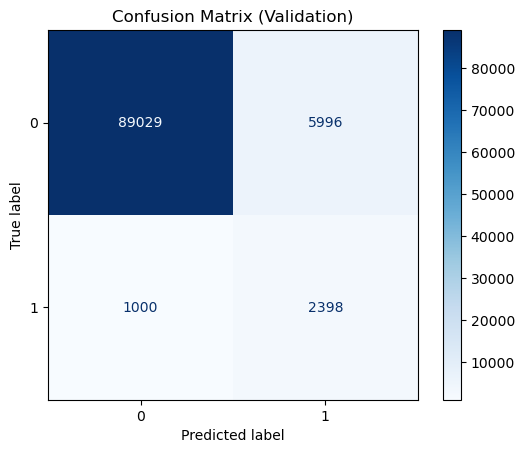

In [37]:
cm = confusion_matrix(y_val, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])

plt.figure(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Confusion Matrix (Validation)')
plt.grid(False)

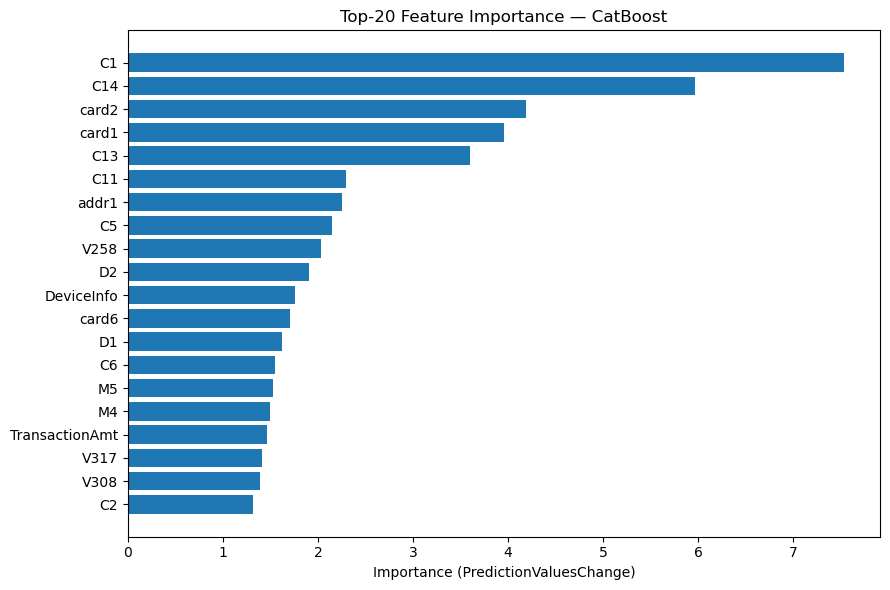

In [38]:
fi = model.get_feature_importance(type="PredictionValuesChange")

fi_df = pd.DataFrame({
    "feature": X.columns,
    "importance": fi
}).sort_values("importance", ascending=False)

top_n = 20
top_fi = fi_df.head(top_n).iloc[::-1]

plt.figure(figsize=(9, 6))
plt.barh(top_fi["feature"], top_fi["importance"])
plt.xlabel("Importance (PredictionValuesChange)")
plt.title("Top-20 Feature Importance — CatBoost")
plt.tight_layout()